# Network Slicing Congestion Forecasting - Complete Analysis Pipeline

## Overview
This notebook performs:
1. **Exploratory Data Analysis (EDA)** - Comprehensive data exploration
2. **Feature Selection** - Using Mutual Information scores
3. **Preprocessing** - Following recommended best practices
4. **LSTM Model** - With complete evaluation
5. **Hyperparameter Tuning** - Coarse to fine optimization

---

In [2]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [3]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.3 MB/s eta 0:00:00


## 1. Setup and Data Loading

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve,
                             average_precision_score, matthews_corrcoef)
from sklearn.ensemble import RandomForestClassifier

# PyTorch for Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Hyperparameter optimization
import optuna
from optuna.samplers import TPESampler

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")
sns.set_style("whitegrid")

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Load dataset
df = pd.read_csv('network_slicing_dataset_enriched_timeseries.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Time Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())

DATASET OVERVIEW
Shape: (21600, 21)
Time Range: 2025-01-01 00:00:00 to 2025-01-03 23:59:00

Columns (21):
['timestamp', 'slice_type', 'slice_id', 'cpu_util_pct', 'mem_util_pct', 'bw_util_pct', 'active_users', 'queue_len', 'congestion_flag', 'Use Case Type', 'Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)', 'Slice Handover']


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Statistics and Data Quality

In [6]:
# Basic statistics
print("="*60)
print("BASIC STATISTICS")
print("="*60)

# Numerical columns
numerical_cols = ['cpu_util_pct', 'mem_util_pct', 'bw_util_pct', 'active_users',
                  'queue_len', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)']

print("\nNumerical Statistics:")
display(df[numerical_cols].describe().round(2))

# Missing values
print("\nMissing Values:")
missing = df.isnull().sum()
print(f"Total missing: {missing.sum()}")
if missing.sum() > 0:
    print(missing[missing > 0])

# Duplicates
print(f"\nDuplicate records: {df.duplicated().sum()}")

BASIC STATISTICS

Numerical Statistics:


,cpu_util_pct,mem_util_pct,bw_util_pct,active_users,queue_len,Slice Latency (ns),Slice Packet Loss,Slice Jitter (ns)
count,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.0,21600.00
mean,69.71,56.00,72.50,138.24,3.78,2115625.30,0.0,2131249.95
std,16.91,12.20,19.25,106.09,5.85,661881.35,0.0,822370.64
min,30.30,28.00,22.70,30.00,0.00,717653.71,0.0,601805.48
25%,60.51,46.56,63.71,59.00,0.00,1785178.54,0.0,1587839.04
50%,69.66,56.86,76.02,80.00,0.00,2297227.78,0.0,2303196.36
75%,82.01,64.92,87.39,219.00,6.00,2495806.84,0.0,2818008.43
max,99.90,82.70,99.90,458.00,26.00,3095878.39,0.0,3408697.10



Missing Values:
Total missing: 0

Duplicate records: 0


### 2.2 Target Variable Analysis

TARGET VARIABLE ANALYSIS

Class Distribution:
  Non-Congested (0): 16550 (76.62%)
  Congested (1): 5050 (23.38%)
  Imbalance Ratio: 3.28:1


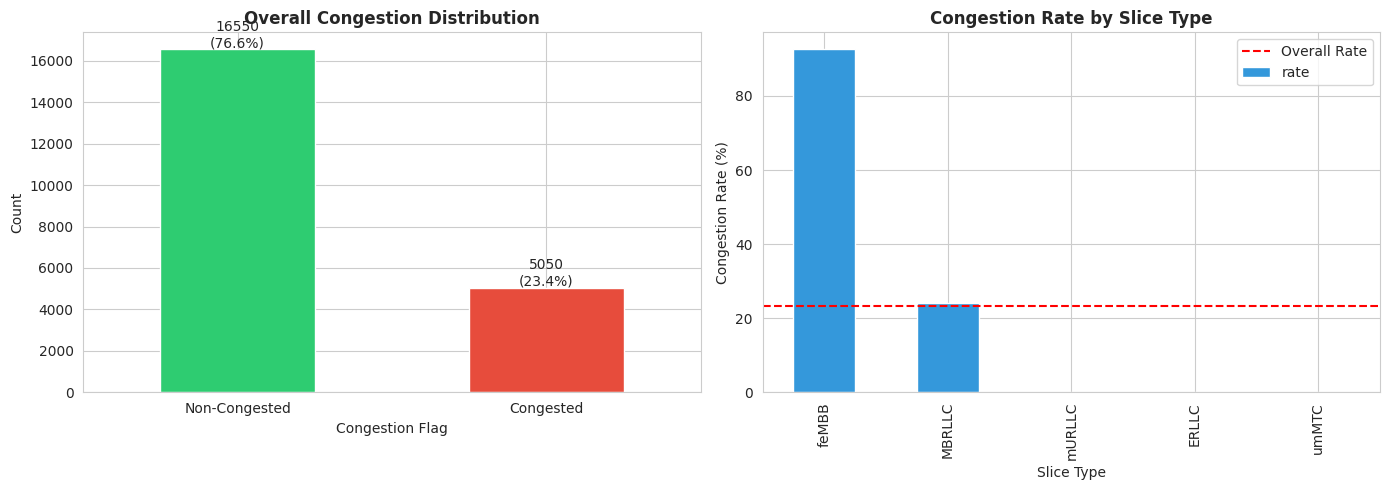

In [7]:
# Target variable distribution
print("="*60)
print("TARGET VARIABLE ANALYSIS")
print("="*60)

congestion_counts = df['congestion_flag'].value_counts()
print(f"\nClass Distribution:")
print(f"  Non-Congested (0): {congestion_counts[0]} ({congestion_counts[0]/len(df)*100:.2f}%)")
print(f"  Congested (1): {congestion_counts[1]} ({congestion_counts[1]/len(df)*100:.2f}%)")
print(f"  Imbalance Ratio: {congestion_counts[0]/congestion_counts[1]:.2f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ax1 = axes[0]
congestion_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax1)
ax1.set_title('Overall Congestion Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Congestion Flag')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Non-Congested', 'Congested'], rotation=0)
for i, v in enumerate(congestion_counts):
    ax1.text(i, v + 100, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# By slice type
ax2 = axes[1]
congestion_by_slice = df.groupby('slice_type')['congestion_flag'].agg(['sum', 'count'])
congestion_by_slice['rate'] = congestion_by_slice['sum'] / congestion_by_slice['count'] * 100
congestion_by_slice['rate'].sort_values(ascending=False).plot(kind='bar', color='#3498db', ax=ax2)
ax2.set_title('Congestion Rate by Slice Type', fontsize=12, fontweight='bold')
ax2.set_xlabel('Slice Type')
ax2.set_ylabel('Congestion Rate (%)')
ax2.axhline(y=df['congestion_flag'].mean()*100, color='red', linestyle='--', label='Overall Rate')
ax2.legend()

plt.tight_layout()
plt.show()

### 2.3 Correlation Analysis

CORRELATION ANALYSIS


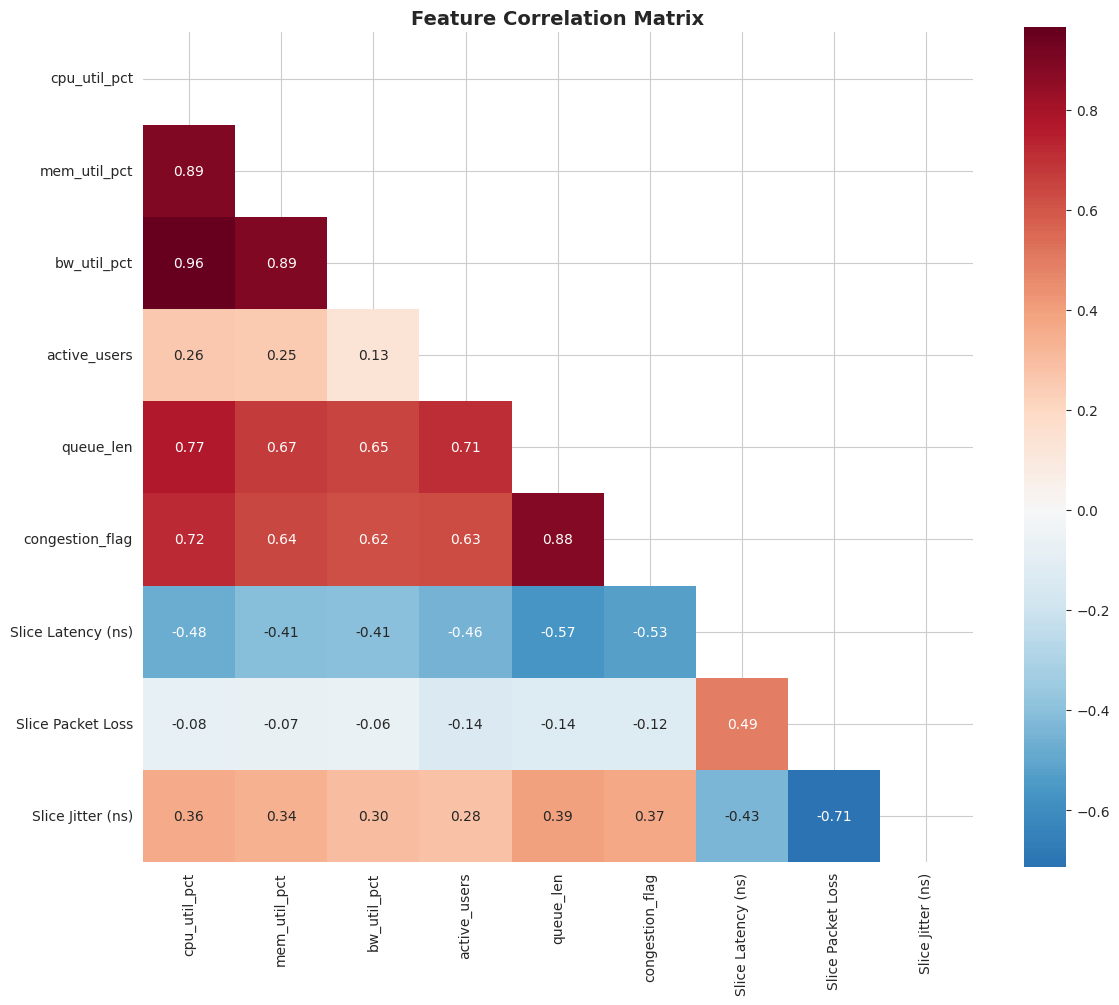


Correlations with congestion_flag:
queue_len             0.882
cpu_util_pct          0.717
mem_util_pct          0.638
active_users          0.628
bw_util_pct           0.620
Slice Latency (ns)   -0.526
Slice Jitter (ns)     0.370
Slice Packet Loss    -0.125
Name: congestion_flag, dtype: float64


In [8]:
# Correlation matrix
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

corr_cols = ['cpu_util_pct', 'mem_util_pct', 'bw_util_pct', 'active_users',
             'queue_len', 'congestion_flag', 'Slice Latency (ns)',
             'Slice Packet Loss', 'Slice Jitter (ns)']

corr_matrix = df[corr_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with target
print("\nCorrelations with congestion_flag:")
target_corr = corr_matrix['congestion_flag'].drop('congestion_flag').sort_values(key=abs, ascending=False)
print(target_corr.round(3))

### 2.4 Resource Utilization Distributions

RESOURCE UTILIZATION DISTRIBUTIONS


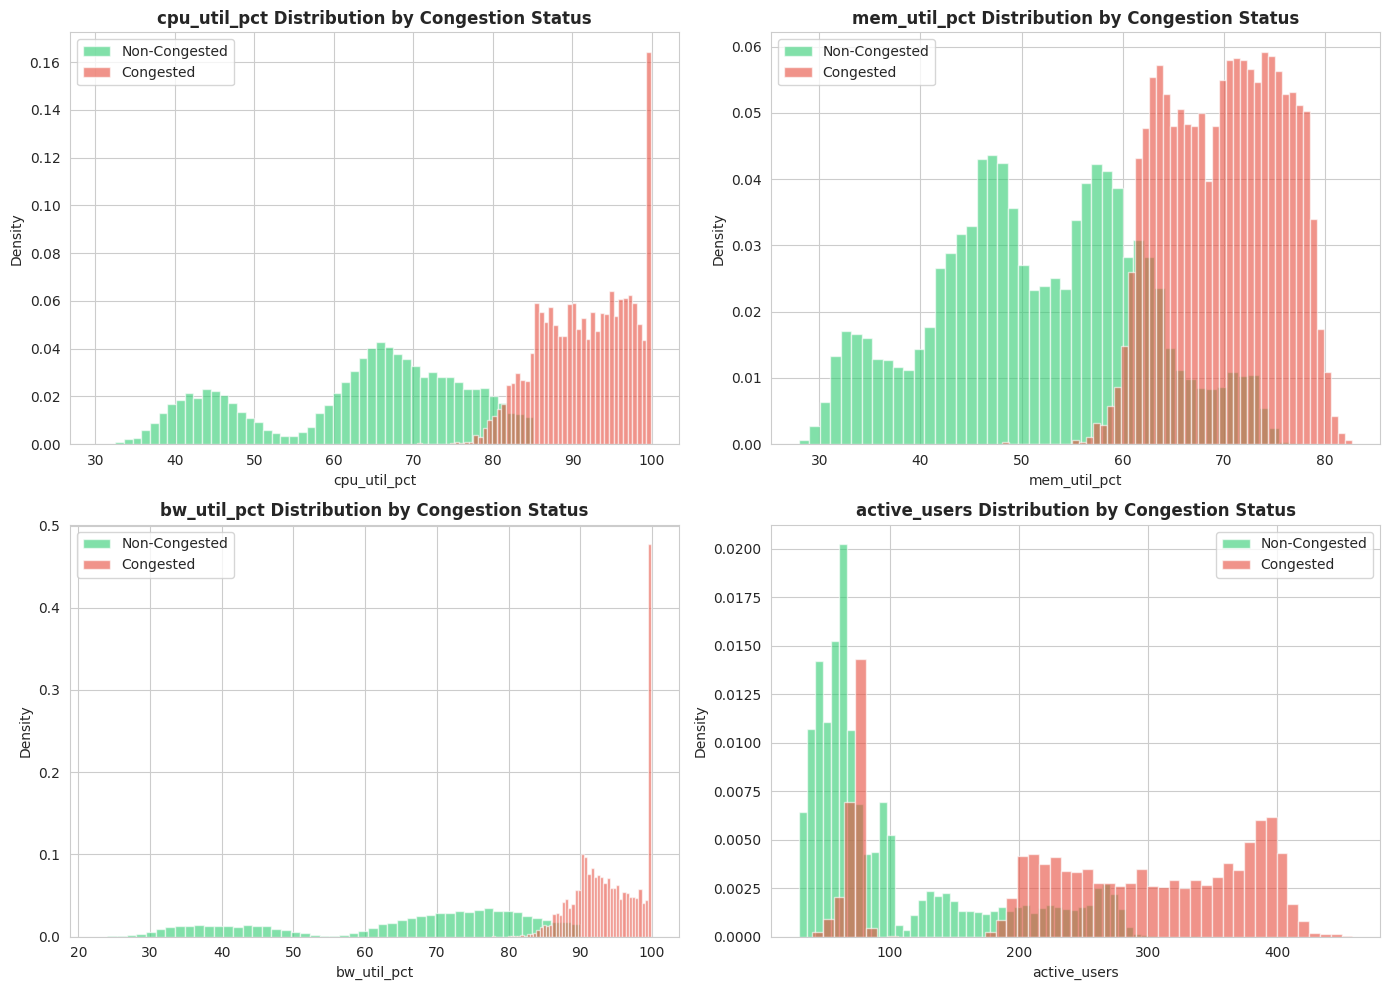

In [9]:
# Resource utilization distributions
print("="*60)
print("RESOURCE UTILIZATION DISTRIBUTIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['cpu_util_pct', 'mem_util_pct', 'bw_util_pct', 'active_users']):
    ax = axes[i//2, i%2]
    for flag in [0, 1]:
        subset = df[df['congestion_flag'] == flag][col]
        label = 'Congested' if flag else 'Non-Congested'
        color = '#e74c3c' if flag else '#2ecc71'
        subset.plot(kind='hist', bins=50, alpha=0.6, label=label, color=color, ax=ax, density=True)
    ax.set_title(f'{col} Distribution by Congestion Status', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()

plt.show()

### 2.5 Queue Length Analysis

QUEUE LENGTH ANALYSIS


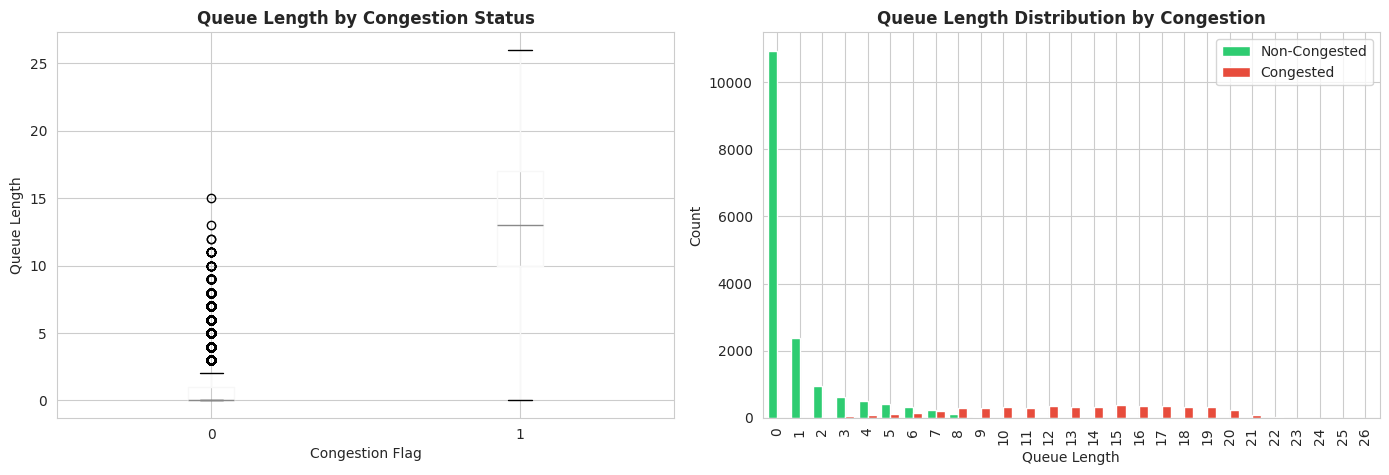


Queue Length Statistics:
  Mean (Congested): 13.11
  Mean (Non-Congested): 0.93


In [10]:
# Queue length analysis
print("="*60)
print("QUEUE LENGTH ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax1 = axes[0]
df.boxplot(column='queue_len', by='congestion_flag', ax=ax1)
ax1.set_title('Queue Length by Congestion Status', fontsize=12, fontweight='bold')
ax1.set_xlabel('Congestion Flag')
ax1.set_ylabel('Queue Length')
plt.suptitle('')

# Queue length distribution
ax2 = axes[1]
queue_by_congestion = df.groupby(['queue_len', 'congestion_flag']).size().unstack(fill_value=0)
queue_by_congestion.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], width=0.8)
ax2.set_title('Queue Length Distribution by Congestion', fontsize=12, fontweight='bold')
ax2.set_xlabel('Queue Length')
ax2.set_ylabel('Count')
ax2.legend(['Non-Congested', 'Congested'])

plt.tight_layout()
plt.show()

# Statistics
print(f"\nQueue Length Statistics:")
print(f"  Mean (Congested): {df[df['congestion_flag']==1]['queue_len'].mean():.2f}")
print(f"  Mean (Non-Congested): {df[df['congestion_flag']==0]['queue_len'].mean():.2f}")

### 2.6 Time Series Patterns

TIME SERIES PATTERNS


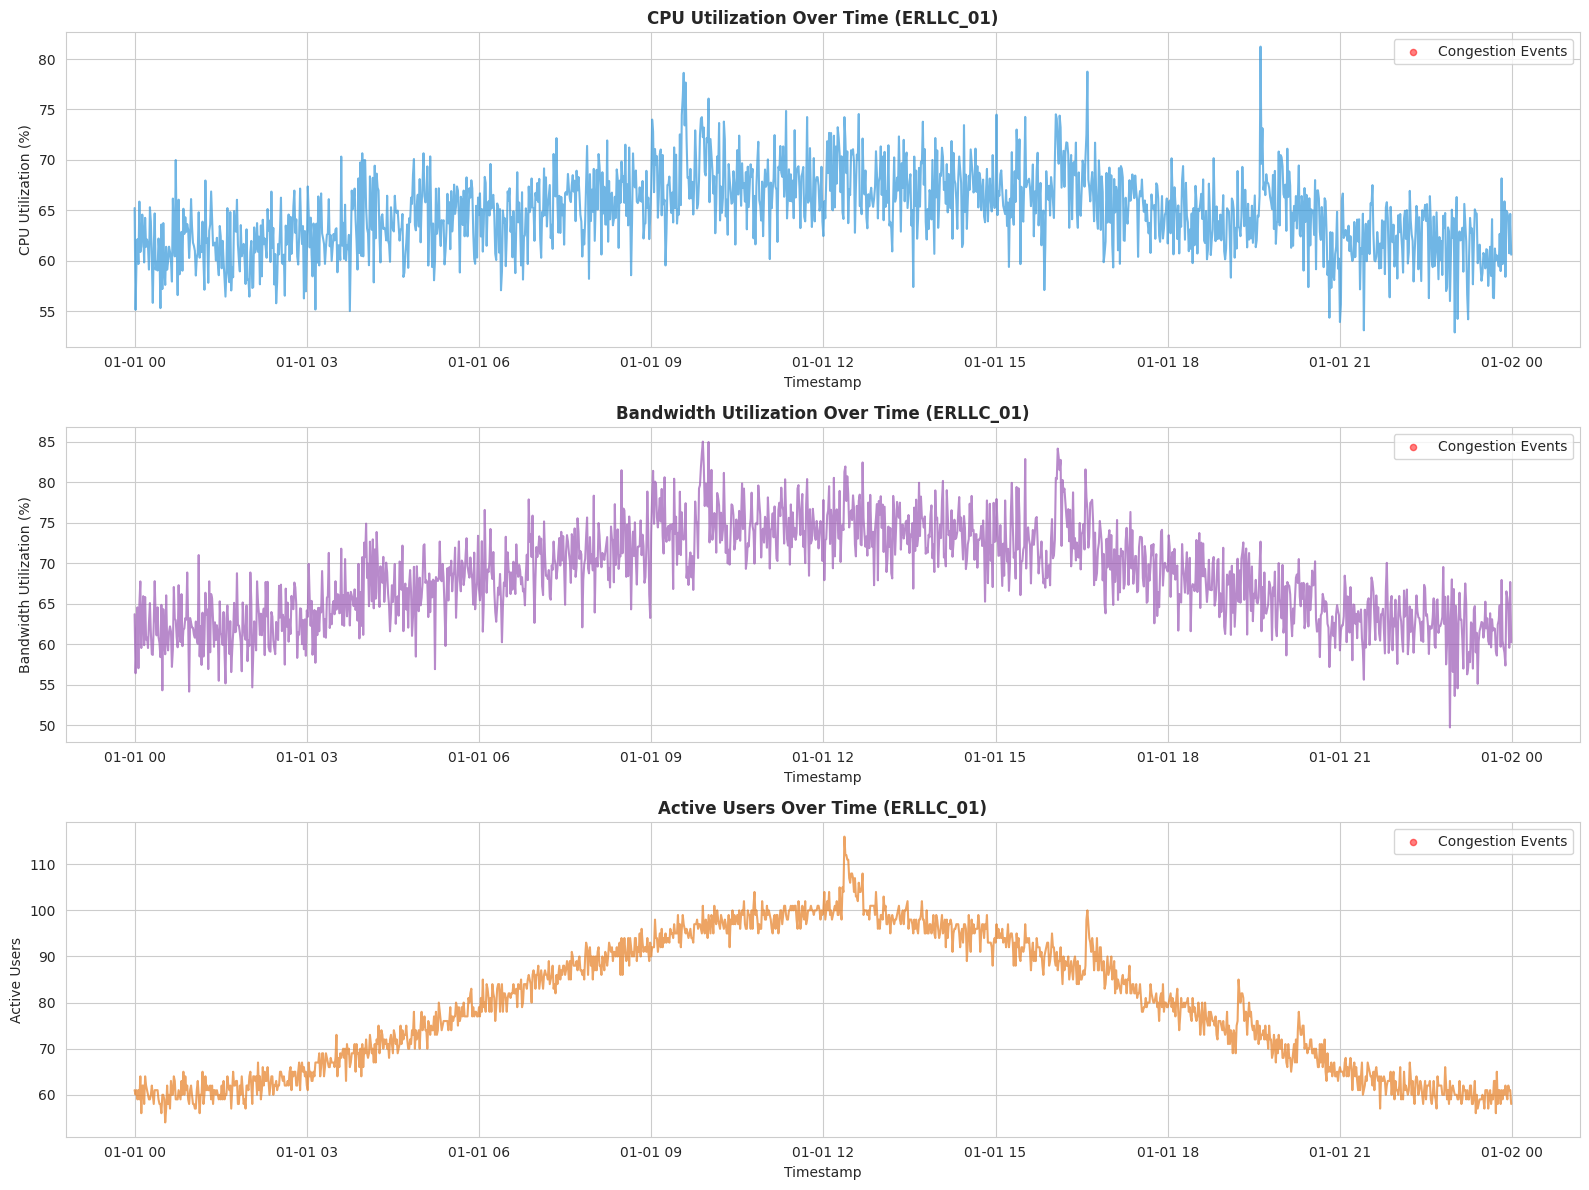

In [11]:
# Time series patterns
print("="*60)
print("TIME SERIES PATTERNS")
print("="*60)

# Sample first slice
sample_slice = df[df['slice_id'] == 'ERLLC_01'].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# CPU utilization
ax1 = axes[0]
ax1.plot(sample_slice['timestamp'], sample_slice['cpu_util_pct'], color='#3498db', alpha=0.7)
congestion_events = sample_slice[sample_slice['congestion_flag'] == 1]
ax1.scatter(congestion_events['timestamp'], congestion_events['cpu_util_pct'],
            color='red', s=20, alpha=0.5, label='Congestion Events')
ax1.set_title('CPU Utilization Over Time (ERLLC_01)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('CPU Utilization (%)')
ax1.legend()

# Bandwidth utilization
ax2 = axes[1]
ax2.plot(sample_slice['timestamp'], sample_slice['bw_util_pct'], color='#9b59b6', alpha=0.7)
ax2.scatter(congestion_events['timestamp'], congestion_events['bw_util_pct'],
            color='red', s=20, alpha=0.5, label='Congestion Events')
ax2.set_title('Bandwidth Utilization Over Time (ERLLC_01)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Timestamp')
ax2.set_ylabel('Bandwidth Utilization (%)')
ax2.legend()

# Active users
ax3 = axes[2]
ax3.plot(sample_slice['timestamp'], sample_slice['active_users'], color='#e67e22', alpha=0.7)
ax3.scatter(congestion_events['timestamp'], congestion_events['active_users'],
            color='red', s=20, alpha=0.5, label='Congestion Events')
ax3.set_title('Active Users Over Time (ERLLC_01)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Timestamp')
ax3.set_ylabel('Active Users')
ax3.legend()

plt.tight_layout()
plt.show()

### 2.7 Hourly Patterns

HOURLY PATTERNS


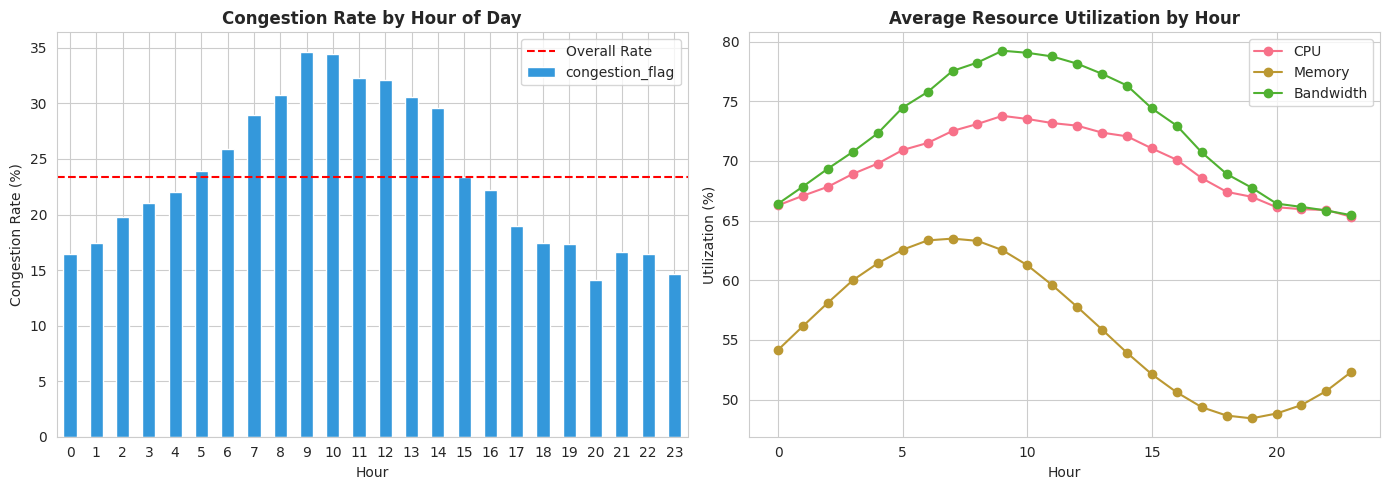


Peak congestion hour: 9 (34.67%)
Lowest congestion hour: 20 (14.11%)


In [12]:
# Hourly patterns
print("="*60)
print("HOURLY PATTERNS")
print("="*60)

df['hour'] = df['timestamp'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Congestion rate by hour
ax1 = axes[0]
hourly_congestion = df.groupby('hour')['congestion_flag'].mean() * 100
hourly_congestion.plot(kind='bar', color='#3498db', ax=ax1)
ax1.set_title('Congestion Rate by Hour of Day', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Congestion Rate (%)')
ax1.axhline(y=df['congestion_flag'].mean()*100, color='red', linestyle='--', label='Overall Rate')
ax1.legend()
ax1.tick_params(axis='x', rotation=0)

# Average metrics by hour
ax2 = axes[1]
hourly_metrics = df.groupby('hour')[['cpu_util_pct', 'mem_util_pct', 'bw_util_pct']].mean()
hourly_metrics.plot(ax=ax2, marker='o')
ax2.set_title('Average Resource Utilization by Hour', fontsize=12, fontweight='bold')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Utilization (%)')
ax2.legend(['CPU', 'Memory', 'Bandwidth'])
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\nPeak congestion hour: {hourly_congestion.idxmax()} ({hourly_congestion.max():.2f}%)")
print(f"Lowest congestion hour: {hourly_congestion.idxmin()} ({hourly_congestion.min():.2f}%)")

### 2.8 Autocorrelation Analysis

In [13]:
# Autocorrelation analysis
print("="*60)
print("AUTOCORRELATION ANALYSIS")
print("="*60)

print("\nAutocorrelation (first slice - ERLLC_01):")
for col in ['cpu_util_pct', 'bw_util_pct', 'queue_len']:
    autocorr_1 = sample_slice[col].autocorr(lag=1)
    autocorr_5 = sample_slice[col].autocorr(lag=5)
    autocorr_10 = sample_slice[col].autocorr(lag=10)
    print(f"  {col}: lag-1={autocorr_1:.3f}, lag-5={autocorr_5:.3f}, lag-10={autocorr_10:.3f}")

AUTOCORRELATION ANALYSIS

Autocorrelation (first slice - ERLLC_01):
  cpu_util_pct: lag-1=0.431, lag-5=0.418, lag-10=0.367
  bw_util_pct: lag-1=0.711, lag-5=0.692, lag-10=0.666
  queue_len: lag-1=0.571, lag-5=0.417, lag-10=0.254


### 2.9 Statistical Significance Tests

In [14]:
# Statistical tests
print("="*60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*60)

statistical_results = []
for col in ['cpu_util_pct', 'mem_util_pct', 'bw_util_pct', 'active_users', 'queue_len']:
    congested = df[df['congestion_flag'] == 1][col]
    non_congested = df[df['congestion_flag'] == 0][col]

    # T-test
    t_stat, t_pvalue = stats.ttest_ind(congested, non_congested)

    # Mann-Whitney U test
    u_stat, u_pvalue = stats.mannwhitneyu(congested, non_congested, alternative='two-sided')

    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(congested)-1)*congested.std()**2 +
                          (len(non_congested)-1)*non_congested.std()**2) /
                         (len(congested) + len(non_congested) - 2))
    cohens_d = (congested.mean() - non_congested.mean()) / pooled_std

    statistical_results.append({
        'Feature': col,
        'Mean (Cong.)': congested.mean(),
        'Mean (Non-Cong.)': non_congested.mean(),
        "Cohen's d": cohens_d,
        'T-test p-value': t_pvalue
    })

stat_df = pd.DataFrame(statistical_results)
display(stat_df.round(4))

print("\nEffect Size Interpretation (Cohen's d):")
print("  d > 0.8: Large effect")
print("  d > 0.5: Medium effect")
print("  d > 0.2: Small effect")

STATISTICAL SIGNIFICANCE TESTS


,Feature,Mean (Cong.),Mean (Non-Cong.),Cohen's d,T-test p-value
0,cpu_util_pct,91.6535,63.0122,2.4299,0.0
1,mem_util_pct,70.0786,51.7012,1.9566,0.0
2,bw_util_pct,94.1202,65.9018,1.8686,0.0
3,active_users,258.9093,101.4230,1.9081,0.0
4,queue_len,13.1101,0.9309,4.4178,0.0



Effect Size Interpretation (Cohen's d):
  d > 0.8: Large effect
  d > 0.5: Medium effect
  d > 0.2: Small effect


---
## 3. Feature Selection using Mutual Information

FEATURE SELECTION - MUTUAL INFORMATION

Mutual Information Scores:


,Feature,MI Score
0,cpu_util_pct,0.4797
2,bw_util_pct,0.4641
4,queue_len,0.4469
6,slice_type_encoded,0.3788
1,mem_util_pct,0.3074
3,active_users,0.2982
5,hour,0.0106


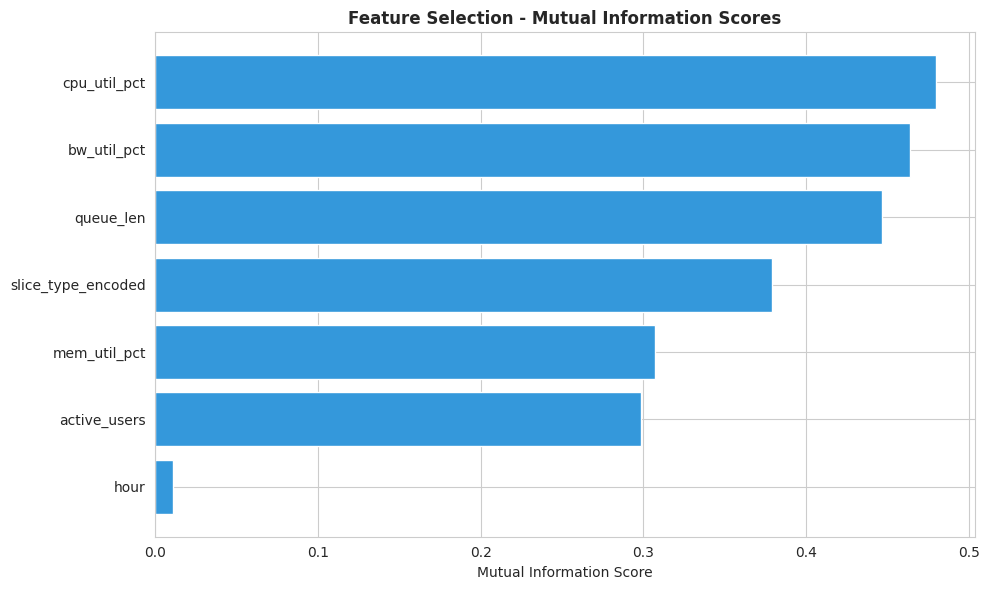


Selected features (MI > 0.01): ['cpu_util_pct', 'bw_util_pct', 'queue_len', 'slice_type_encoded', 'mem_util_pct', 'active_users', 'hour']


In [15]:
# Feature selection using Mutual Information
print("="*60)
print("FEATURE SELECTION - MUTUAL INFORMATION")
print("="*60)

# Prepare features for MI calculation
df_fs = df.copy()

# Encode categorical variables
le = LabelEncoder()
df_fs['slice_type_encoded'] = le.fit_transform(df_fs['slice_type'])

# Select candidate features
feature_candidates = [
    'cpu_util_pct', 'mem_util_pct', 'bw_util_pct',
    'active_users', 'queue_len', 'hour', 'slice_type_encoded'
]

X_fs = df_fs[feature_candidates].values
y_fs = df_fs['congestion_flag'].values

# Calculate MI scores
mi_scores = mutual_info_classif(X_fs, y_fs, random_state=42)

# Create DataFrame
mi_df = pd.DataFrame({
    'Feature': feature_candidates,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print("\nMutual Information Scores:")
display(mi_df.round(4))

# Plot MI scores
fig, ax = plt.subplots(figsize=(10, 6))
mi_df_sorted = mi_df.sort_values('MI Score', ascending=True)
ax.barh(mi_df_sorted['Feature'], mi_df_sorted['MI Score'], color='#3498db')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Selection - Mutual Information Scores', fontsize=12, fontweight='bold')
plt.tight_layout()

plt.show()

# Select features above threshold
threshold = 0.01
selected_features = mi_df[mi_df['MI Score'] > threshold]['Feature'].tolist()
print(f"\nSelected features (MI > {threshold}): {selected_features}")

In [16]:
# Random Forest feature importance for comparison
print("\nRandom Forest Feature Importance (Comparison):")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_fs, y_fs)

rf_importance = pd.DataFrame({
    'Feature': feature_candidates,
    'RF Importance': rf.feature_importances_
}).sort_values('RF Importance', ascending=False)

display(rf_importance.round(4))

# Combined view
combined_fs = mi_df.merge(rf_importance, on='Feature')
combined_fs['Average_Rank'] = (combined_fs['MI Score'].rank(ascending=False) +
                                combined_fs['RF Importance'].rank(ascending=False)) / 2
combined_fs = combined_fs.sort_values('Average_Rank')

print("\nCombined Feature Ranking:")
display(combined_fs.round(4))


Random Forest Feature Importance (Comparison):


,Feature,RF Importance
0,cpu_util_pct,0.3505
2,bw_util_pct,0.2419
4,queue_len,0.2387
1,mem_util_pct,0.1072
3,active_users,0.0340
6,slice_type_encoded,0.0245
5,hour,0.0033



Combined Feature Ranking:


,Feature,MI Score,RF Importance,Average_Rank
0,cpu_util_pct,0.4797,0.3505,1.0
1,bw_util_pct,0.4641,0.2419,2.0
2,queue_len,0.4469,0.2387,3.0
4,mem_util_pct,0.3074,0.1072,4.5
3,slice_type_encoded,0.3788,0.0245,5.0
5,active_users,0.2982,0.0340,5.5
6,hour,0.0106,0.0033,7.0


---
## 4. Preprocessing Pipeline

In [17]:
# Preprocessing pipeline - FIXED: Slice-wise temporal split
print("="*60)
print("PREPROCESSING PIPELINE")
print("="*60)

# Pre-encode slice_type on ENTIRE dataset
slice_encoder = LabelEncoder()
df['slice_type_encoded'] = slice_encoder.fit_transform(df['slice_type'])
df['hour'] = df['timestamp'].dt.hour

print(f"\nSlice type encoding mapping:")
for i, label in enumerate(slice_encoder.classes_):
    print(f"  {label} -> {i}")

# SLICE-WISE TEMPORAL SPLIT
# This ensures each slice type is represented in train/val/test
# while maintaining temporal order within each slice

def slice_wise_temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    '''
    Split data by slice, maintaining temporal order within each slice.
    This ensures all slice types are represented in train/val/test.
    '''
    train_dfs = []
    val_dfs = []
    test_dfs = []

    for slice_id in df['slice_id'].unique():
        slice_df = df[df['slice_id'] == slice_id].sort_values('timestamp')
        n = len(slice_df)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))

        train_dfs.append(slice_df.iloc[:train_end])
        val_dfs.append(slice_df.iloc[train_end:val_end])
        test_dfs.append(slice_df.iloc[val_end:])

    return pd.concat(train_dfs), pd.concat(val_dfs), pd.concat(test_dfs)

# Apply slice-wise split
df_train, df_val, df_test = slice_wise_temporal_split(df, train_ratio=0.6, val_ratio=0.2)

print(f"\nData Split (Slice-wise Temporal):")
print(f"  Training: {len(df_train)} samples ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Validation: {len(df_val)} samples ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test: {len(df_test)} samples ({len(df_test)/len(df)*100:.1f}%)")

# Verify all slice types are present in each split
print(f"\nSlice types in each split:")
print(f"  Train: {sorted(df_train['slice_type'].unique())}")
print(f"  Val: {sorted(df_val['slice_type'].unique())}")
print(f"  Test: {sorted(df_test['slice_type'].unique())}")

# Verify congestion distribution in each split
print(f"\nCongestion distribution in each split:")
print(f"  Train: {df_train['congestion_flag'].mean()*100:.2f}% congested")
print(f"  Val: {df_val['congestion_flag'].mean()*100:.2f}% congested")
print(f"  Test: {df_test['congestion_flag'].mean()*100:.2f}% congested")

PREPROCESSING PIPELINE

Slice type encoding mapping:
  ERLLC -> 0
  MBRLLC -> 1
  feMBB -> 2
  mURLLC -> 3
  umMTC -> 4

Data Split (Slice-wise Temporal):
  Training: 12960 samples (60.0%)
  Validation: 4320 samples (20.0%)
  Test: 4320 samples (20.0%)

Slice types in each split:
  Train: ['ERLLC', 'MBRLLC', 'feMBB', 'mURLLC', 'umMTC']
  Val: ['ERLLC', 'MBRLLC', 'feMBB', 'mURLLC', 'umMTC']
  Test: ['ERLLC', 'MBRLLC', 'feMBB', 'mURLLC', 'umMTC']

Congestion distribution in each split:
  Train: 26.60% congested
  Val: 21.25% congested
  Test: 15.83% congested


In [18]:
# Complete preprocessing class
class Preprocessor:
    '''Complete preprocessing pipeline for congestion forecasting'''

    def __init__(self, seq_length=30):
        self.seq_length = seq_length
        self.scaler = StandardScaler()
        self.feature_cols = None

    def fit(self, df):
        '''Fit preprocessors on training data'''
        self.feature_cols = [
            'cpu_util_pct', 'mem_util_pct', 'bw_util_pct',
            'active_users', 'queue_len', 'hour', 'slice_type_encoded'
        ]
        self.scaler.fit(df[self.feature_cols].values)
        return self

    def transform(self, df):
        '''Transform data using fitted preprocessors'''
        features_scaled = self.scaler.transform(df[self.feature_cols].values)
        return features_scaled, df['congestion_flag'].values

    def create_sequences_by_slice(self, df, features, target):
        '''Create sequences within each slice_id to avoid cross-slice contamination'''
        X, y, slice_ids = [], [], []

        for slice_id in df['slice_id'].unique():
            slice_mask = df['slice_id'].values == slice_id
            slice_features = features[slice_mask]
            slice_target = target[slice_mask]

            for i in range(len(slice_features) - self.seq_length):
                X.append(slice_features[i:i+self.seq_length])
                y.append(slice_target[i+self.seq_length])
                slice_ids.append(slice_id)

        return np.array(X), np.array(y), np.array(slice_ids)

# Initialize preprocessor
preprocessor = Preprocessor(seq_length=30)

# Fit and transform
preprocessor.fit(df_train)

X_train_raw, y_train_raw = preprocessor.transform(df_train)
X_val_raw, y_val_raw = preprocessor.transform(df_val)
X_test_raw, y_test_raw = preprocessor.transform(df_test)

# Create sequences (within each slice)
X_train, y_train, train_slices = preprocessor.create_sequences_by_slice(df_train, X_train_raw, y_train_raw)
X_val, y_val, val_slices = preprocessor.create_sequences_by_slice(df_val, X_val_raw, y_val_raw)
X_test, y_test, test_slices = preprocessor.create_sequences_by_slice(df_test, X_test_raw, y_test_raw)

print(f"\nSequence Shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")

# Calculate class weights
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio (for loss weighting): {pos_weight:.2f}:1")


Sequence Shapes:
  X_train: (12510, 30, 7), y_train: (12510,)
  X_val: (3870, 30, 7), y_val: (3870,)
  X_test: (3870, 30, 7), y_test: (3870,)

Class imbalance ratio (for loss weighting): 2.71:1


In [19]:
# Create PyTorch datasets
class CongestionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create dataloaders
batch_size = 256

train_dataset = CongestionDataset(X_train, y_train)
val_dataset = CongestionDataset(X_val, y_val)
test_dataset = CongestionDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoader batch sizes: {batch_size}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


DataLoader batch sizes: 256
  Training batches: 49
  Validation batches: 16
  Test batches: 16


---
## 5. LSTM Model Definition

In [20]:
# LSTM Model Definition
print("="*60)
print("LSTM MODEL DEFINITION")
print("="*60)

class FocalLoss(nn.Module):
    '''Focal Loss for handling class imbalance'''
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return F_loss.mean()

class LSTMClassifier(nn.Module):
    '''LSTM-based binary classifier for congestion prediction'''

    def __init__(self, input_dim, hidden_dim=64, num_layers=2,
                 dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        direction_mult = 2 if bidirectional else 1

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * direction_mult, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n//4:n//2].fill_(1)

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)

        if self.bidirectional:
            hidden_last = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_last = hidden[-1]

        out = self.fc(hidden_last)
        return out.squeeze(-1)

# Initialize model
input_dim = X_train.shape[2]
model = LSTMClassifier(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
).to(device)

print(f"\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTM MODEL DEFINITION

Model Architecture:
LSTMClassifier(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 147,073


---
## 6. Training Functions

In [21]:
# Training and evaluation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(train_loader)

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()

            all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    auc = roc_auc_score(all_labels, all_preds)

    return avg_loss, auc, all_preds, all_labels

def find_optimal_threshold(probs, labels):
    '''Find optimal threshold using Youden's J statistic'''
    fpr, tpr, thresholds = roc_curve(labels, probs)
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    return thresholds[optimal_idx]

def evaluate_model(model, test_loader, device, threshold=0.5):
    '''Comprehensive model evaluation'''
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs >= threshold).astype(int)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(batch_y.numpy())

    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds),
        'recall': recall_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds),
        'auc_roc': roc_auc_score(all_labels, all_probs),
        'auc_pr': average_precision_score(all_labels, all_probs)
    }

    cm = confusion_matrix(all_labels, all_preds)

    return metrics, cm, all_probs, all_labels

---
## 7. Initial LSTM Training (Coarse)

In [22]:
# Initial training with default hyperparameters
print("="*60)
print("INITIAL LSTM TRAINING (COARSE)")
print("="*60)

def train_model(model, train_loader, val_loader, device, epochs=30, lr=0.001,
                use_focal_loss=True, pos_weight=None, verbose=True):
    '''Train the LSTM model'''

    if use_focal_loss:
        criterion = FocalLoss(alpha=0.75, gamma=2.0)
    else:
        weight = torch.tensor([pos_weight]).to(device) if pos_weight else None
        criterion = nn.BCEWithLogitsLoss(pos_weight=weight)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    best_val_auc = 0
    best_model_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_auc, _, _ = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = model.state_dict().copy()

        if verbose and (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val AUC={val_auc:.4f}")

    model.load_state_dict(best_model_state)
    return model, history

# Train initial model
model_initial = LSTMClassifier(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
).to(device)

model_initial, history_initial = train_model(
    model_initial, train_loader, val_loader, device,
    epochs=30, lr=0.001, use_focal_loss=True, pos_weight=pos_weight
)

print(f"\nBest Validation AUC: {max(history_initial['val_auc']):.4f}")

INITIAL LSTM TRAINING (COARSE)
Epoch   5: Train Loss=0.0236, Val Loss=0.0308, Val AUC=0.9919
Epoch  10: Train Loss=0.0226, Val Loss=0.0349, Val AUC=0.9920
Epoch  15: Train Loss=0.0218, Val Loss=0.0372, Val AUC=0.9920
Epoch  20: Train Loss=0.0216, Val Loss=0.0361, Val AUC=0.9919
Epoch  25: Train Loss=0.0218, Val Loss=0.0364, Val AUC=0.9918
Epoch  30: Train Loss=0.0216, Val Loss=0.0362, Val AUC=0.9917

Best Validation AUC: 0.9921


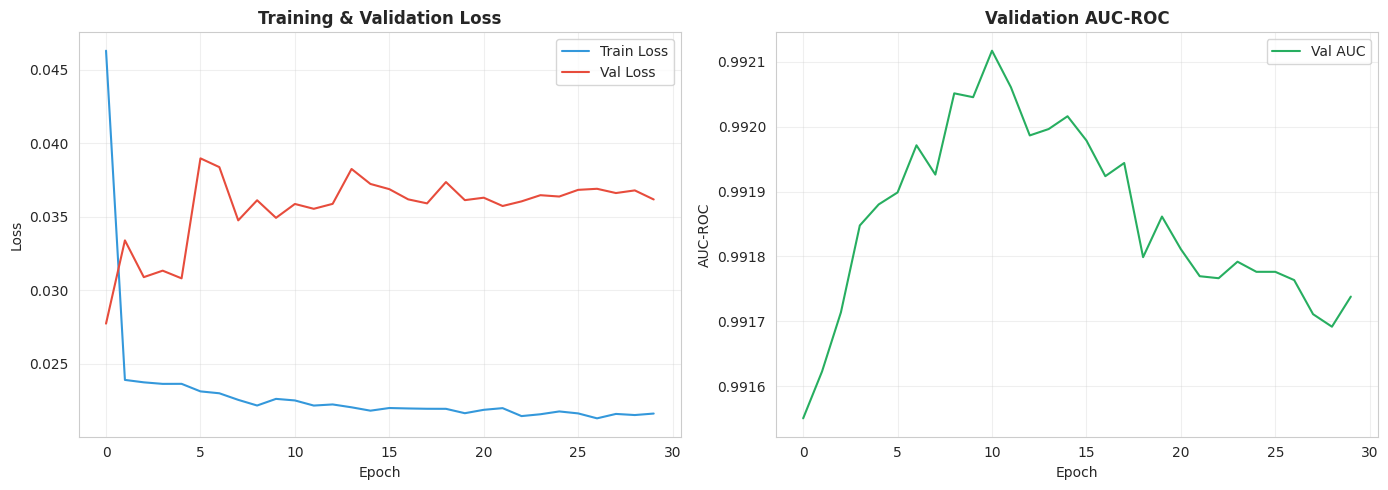

In [23]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1 = axes[0]
ax1.plot(history_initial['train_loss'], label='Train Loss', color='#3498db')
ax1.plot(history_initial['val_loss'], label='Val Loss', color='#e74c3c')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AUC curve
ax2 = axes[1]
ax2.plot(history_initial['val_auc'], label='Val AUC', color='#27ae60')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC-ROC')
ax2.set_title('Validation AUC-ROC', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Evaluate initial model
print("="*60)
print("INITIAL MODEL EVALUATION")
print("="*60)

# Find optimal threshold
_, _, val_probs, val_labels = evaluate_model(model_initial, val_loader, device)
optimal_threshold = find_optimal_threshold(val_probs, val_labels)
print(f"Optimal threshold: {optimal_threshold:.3f}")

# Test set evaluation
metrics_initial, cm_initial, test_probs, test_labels = evaluate_model(
    model_initial, test_loader, device, threshold=optimal_threshold
)

print("\nTest Set Performance (Initial Model):")
for metric, value in metrics_initial.items():
    print(f"  {metric}: {value:.4f}")

print(f"\nConfusion Matrix:\n{cm_initial}")

INITIAL MODEL EVALUATION
Optimal threshold: 0.484

Test Set Performance (Initial Model):
  accuracy: 0.9506
  precision: 0.7661
  recall: 0.9834
  f1: 0.8613
  auc_roc: 0.9761
  auc_pr: 0.8177

Confusion Matrix:
[[3086  181]
 [  10  593]]


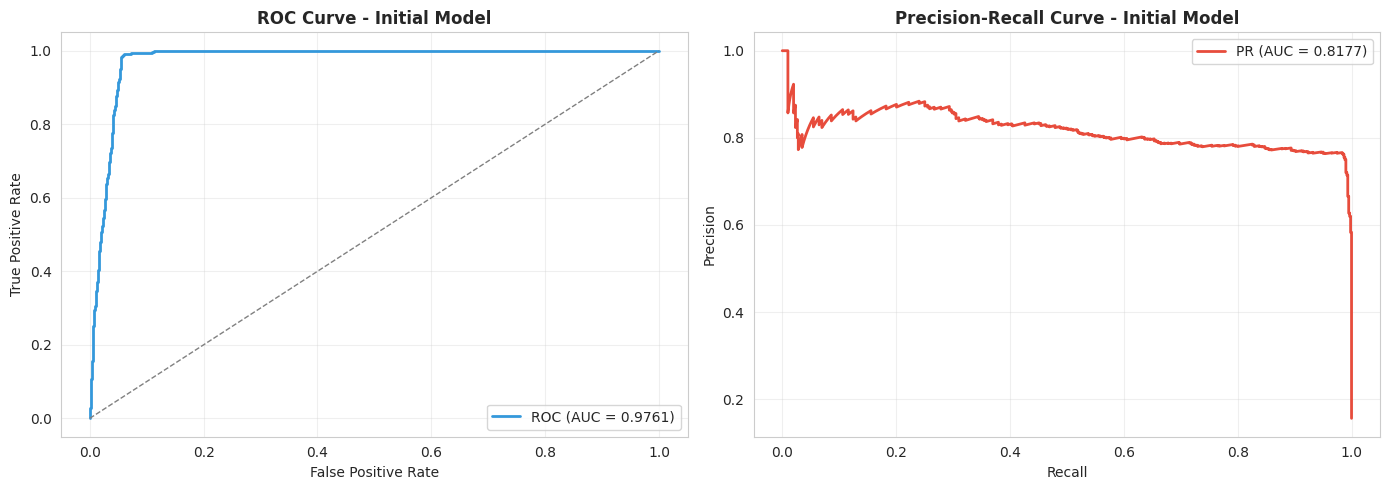

In [25]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1 = axes[0]
fpr, tpr, _ = roc_curve(test_labels, test_probs)
ax1.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC (AUC = {metrics_initial["auc_roc"]:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve - Initial Model', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# PR Curve
ax2 = axes[1]
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
ax2.plot(recall, precision, color='#e74c3c', lw=2,
         label=f'PR (AUC = {metrics_initial["auc_pr"]:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve - Initial Model', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Tuning - Coarse to Fine

In [26]:
# Coarse to Fine Hyperparameter Tuning with Optuna
print("="*60)
print("HYPERPARAMETER TUNING - COARSE TO FINE")
print("="*60)

def objective_coarse(trial):
    '''Coarse search objective'''
    # Coarse hyperparameter ranges
    hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_categorical('dropout', [0.2, 0.3, 0.4])
    lr = trial.suggest_categorical('lr', [1e-4, 5e-4, 1e-3])
    bidirectional = trial.suggest_categorical('bidirectional', [True, False])

    # Build model
    model = LSTMClassifier(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=bidirectional
    ).to(device)

    # Train with fewer epochs for coarse search
    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    best_val_auc = 0
    for epoch in range(15):  # Fewer epochs for coarse search
        train_epoch(model, train_loader, criterion, optimizer, device)
        _, val_auc, _, _ = validate(model, val_loader, criterion, device)
        best_val_auc = max(best_val_auc, val_auc)

    return best_val_auc

# Run coarse search
print("\n--- COARSE SEARCH ---")
study_coarse = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_coarse.optimize(objective_coarse, n_trials=20, show_progress_bar=True)

print(f"\nCoarse Search Best Trial:")
print(f"  Value (AUC): {study_coarse.best_trial.value:.4f}")
print(f"  Params: {study_coarse.best_trial.params}")

[I 2026-04-08 11:03:43,709] A new study created in memory with name: no-name-7a10e903-e9ab-402f-873a-e1aebbcf5980


HYPERPARAMETER TUNING - COARSE TO FINE

--- COARSE SEARCH ---


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-08 11:03:50,813] Trial 0 finished with value: 0.990943202367253 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.0001, 'bidirectional': False}. Best is trial 0 with value: 0.990943202367253.
[I 2026-04-08 11:03:55,059] Trial 1 finished with value: 0.9920203846786125 and parameters: {'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.0005, 'bidirectional': False}. Best is trial 1 with value: 0.9920203846786125.
[I 2026-04-08 11:04:00,426] Trial 2 finished with value: 0.992286700641131 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.001, 'bidirectional': True}. Best is trial 2 with value: 0.992286700641131.
[I 2026-04-08 11:04:07,751] Trial 3 finished with value: 0.9913221272398487 and parameters: {'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.0001, 'bidirectional': False}. Best is trial 2 with value: 0.992286700641131.
[I 2026-04-08 11:04:17,731] Trial 4 finished with value: 0.9910673187571921 and pa

In [27]:
# Fine search based on coarse results
best_coarse = study_coarse.best_trial.params

def objective_fine(trial):
    '''Fine search objective - narrower ranges around coarse best'''
    # Fine hyperparameter ranges around coarse best
    if best_coarse['hidden_dim'] == 32:
        hidden_dim = trial.suggest_int('hidden_dim', 24, 48)
    elif best_coarse['hidden_dim'] == 64:
        hidden_dim = trial.suggest_int('hidden_dim', 48, 96)
    else:
        hidden_dim = trial.suggest_int('hidden_dim', 96, 160)

    num_layers = best_coarse['num_layers']  # Keep from coarse

    dropout = trial.suggest_float('dropout',
                                   max(0.1, best_coarse['dropout'] - 0.1),
                                   min(0.5, best_coarse['dropout'] + 0.1))

    lr = trial.suggest_float('lr',
                             best_coarse['lr'] * 0.5,
                             best_coarse['lr'] * 2.0,
                             log=True)

    bidirectional = best_coarse['bidirectional']

    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    # Recreate dataloaders with new batch size
    train_loader_fine = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_fine = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Build model
    model = LSTMClassifier(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=bidirectional
    ).to(device)

    # Train with more epochs for fine search
    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    best_val_auc = 0
    patience_counter = 0

    for epoch in range(30):  # More epochs for fine search
        train_epoch(model, train_loader_fine, criterion, optimizer, device)
        _, val_auc, _, _ = validate(model, val_loader_fine, criterion, device)
        scheduler.step(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 7:  # Early stopping
                break

    return best_val_auc

# Run fine search
print("\n--- FINE SEARCH ---")
study_fine = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_fine.optimize(objective_fine, n_trials=15, show_progress_bar=True)

print(f"\nFine Search Best Trial:")
print(f"  Value (AUC): {study_fine.best_trial.value:.4f}")
print(f"  Params: {study_fine.best_trial.params}")

[I 2026-04-08 11:07:52,890] A new study created in memory with name: no-name-247534e6-b3b3-45a0-a511-0adbd12b80b2



--- FINE SEARCH ---


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-04-08 11:08:03,218] Trial 0 finished with value: 0.9924736971888871 and parameters: {'hidden_dim': 120, 'dropout': 0.49014286128198326, 'lr': 0.0013793493374058524, 'batch_size': 128}. Best is trial 0 with value: 0.9924736971888871.
[I 2026-04-08 11:08:28,108] Trial 1 finished with value: 0.9922260808811442 and parameters: {'hidden_dim': 99, 'dropout': 0.47323522915498706, 'lr': 0.0011504753106625046, 'batch_size': 512}. Best is trial 0 with value: 0.9924736971888871.
[I 2026-04-08 11:09:14,694] Trial 2 finished with value: 0.9921239519973696 and parameters: {'hidden_dim': 150, 'dropout': 0.34246782213565524, 'lr': 0.0006433385005697076, 'batch_size': 512}. Best is trial 0 with value: 0.9924736971888871.
[I 2026-04-08 11:09:34,212] Trial 3 finished with value: 0.9924831497616308 and parameters: {'hidden_dim': 124, 'dropout': 0.3582458280396084, 'lr': 0.0011677292338861146, 'batch_size': 512}. Best is trial 3 with value: 0.9924831497616308.
[I 2026-04-08 11:09:46,436] Trial 4 fi

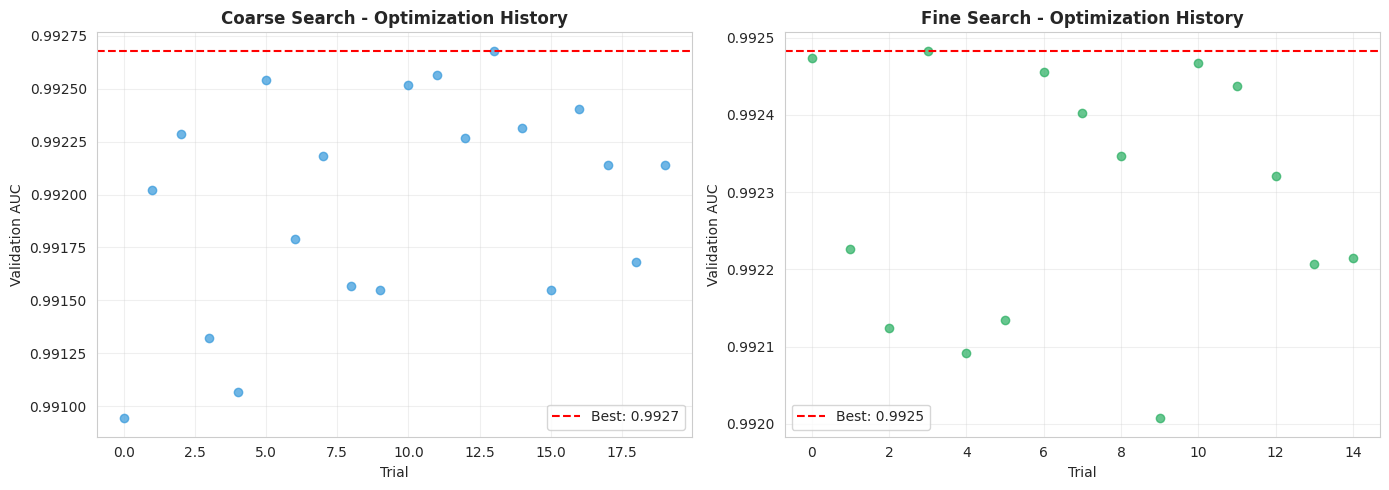

In [28]:
# Visualization of optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coarse search
ax1 = axes[0]
trials_coarse = [t.value for t in study_coarse.trials]
ax1.scatter(range(len(trials_coarse)), trials_coarse, c='#3498db', alpha=0.7)
ax1.axhline(y=study_coarse.best_trial.value, color='red', linestyle='--', label=f'Best: {study_coarse.best_trial.value:.4f}')
ax1.set_xlabel('Trial')
ax1.set_ylabel('Validation AUC')
ax1.set_title('Coarse Search - Optimization History', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fine search
ax2 = axes[1]
trials_fine = [t.value for t in study_fine.trials]
ax2.scatter(range(len(trials_fine)), trials_fine, c='#27ae60', alpha=0.7)
ax2.axhline(y=study_fine.best_trial.value, color='red', linestyle='--', label=f'Best: {study_fine.best_trial.value:.4f}')
ax2.set_xlabel('Trial')
ax2.set_ylabel('Validation AUC')
ax2.set_title('Fine Search - Optimization History', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Final Model Training with Optimal Hyperparameters

In [29]:
# Train final model with optimal hyperparameters
print("="*60)
print("FINAL MODEL TRAINING")
print("="*60)

# Get best hyperparameters
best_params = study_fine.best_trial.params
best_hidden_dim = best_params.get('hidden_dim', best_coarse['hidden_dim'])
best_batch_size = best_params.get('batch_size', 256)
best_dropout = best_params.get('dropout', best_coarse['dropout'])
best_lr = best_params.get('lr', best_coarse['lr'])

print(f"\nOptimal Hyperparameters:")
print(f"  hidden_dim: {best_hidden_dim}")
print(f"  num_layers: {best_coarse['num_layers']}")
print(f"  dropout: {best_dropout:.3f}")
print(f"  learning_rate: {best_lr:.6f}")
print(f"  bidirectional: {best_coarse['bidirectional']}")
print(f"  batch_size: {best_batch_size}")

# Create final dataloaders
train_loader_final = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
val_loader_final = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False)
test_loader_final = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

# Build final model
model_final = LSTMClassifier(
    input_dim=input_dim,
    hidden_dim=best_hidden_dim,
    num_layers=best_coarse['num_layers'],
    dropout=best_dropout,
    bidirectional=best_coarse['bidirectional']
).to(device)

print(f"\nFinal Model Parameters: {sum(p.numel() for p in model_final.parameters()):,}")

# Train final model
model_final, history_final = train_model(
    model_final, train_loader_final, val_loader_final, device,
    epochs=50, lr=best_lr, use_focal_loss=True, pos_weight=pos_weight
)

print(f"\nFinal Model - Best Validation AUC: {max(history_final['val_auc']):.4f}")

FINAL MODEL TRAINING

Optimal Hyperparameters:
  hidden_dim: 124
  num_layers: 2
  dropout: 0.358
  learning_rate: 0.001168
  bidirectional: True
  batch_size: 512

Final Model Parameters: 520,993
Epoch   5: Train Loss=0.0242, Val Loss=0.0345, Val AUC=0.9920
Epoch  10: Train Loss=0.0228, Val Loss=0.0323, Val AUC=0.9922
Epoch  15: Train Loss=0.0229, Val Loss=0.0343, Val AUC=0.9924
Epoch  20: Train Loss=0.0225, Val Loss=0.0326, Val AUC=0.9924
Epoch  25: Train Loss=0.0220, Val Loss=0.0351, Val AUC=0.9924
Epoch  30: Train Loss=0.0216, Val Loss=0.0379, Val AUC=0.9921
Epoch  35: Train Loss=0.0218, Val Loss=0.0362, Val AUC=0.9919
Epoch  40: Train Loss=0.0218, Val Loss=0.0361, Val AUC=0.9918
Epoch  45: Train Loss=0.0218, Val Loss=0.0363, Val AUC=0.9918
Epoch  50: Train Loss=0.0214, Val Loss=0.0363, Val AUC=0.9917

Final Model - Best Validation AUC: 0.9924


In [30]:
# Final evaluation
print("="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

# Find optimal threshold on validation set
_, _, val_probs_final, val_labels_final = evaluate_model(model_final, val_loader_final, device)
optimal_threshold_final = find_optimal_threshold(val_probs_final, val_labels_final)
print(f"Optimal threshold: {optimal_threshold_final:.3f}")

# Test set evaluation
metrics_final, cm_final, test_probs_final, test_labels_final = evaluate_model(
    model_final, test_loader_final, device, threshold=optimal_threshold_final
)

print("\nFinal Test Set Performance:")
for metric, value in metrics_final.items():
    print(f"  {metric}: {value:.4f}")

print(f"\nConfusion Matrix:\n{cm_final}")

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels_final,
                           (np.array(test_probs_final) >= optimal_threshold_final).astype(int),
                           target_names=['Non-Congested', 'Congested']))

FINAL MODEL EVALUATION
Optimal threshold: 0.464

Final Test Set Performance:
  accuracy: 0.9506
  precision: 0.7661
  recall: 0.9834
  f1: 0.8613
  auc_roc: 0.9770
  auc_pr: 0.8231

Confusion Matrix:
[[3086  181]
 [  10  593]]

Classification Report:
               precision    recall  f1-score   support

Non-Congested       1.00      0.94      0.97      3267
    Congested       0.77      0.98      0.86       603

     accuracy                           0.95      3870
    macro avg       0.88      0.96      0.92      3870
 weighted avg       0.96      0.95      0.95      3870



In [31]:
# Comparison: Initial vs Final
print("\n" + "="*60)
print("MODEL COMPARISON: INITIAL vs FINAL")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': list(metrics_initial.keys()),
    'Initial Model': list(metrics_initial.values()),
    'Final Model': list(metrics_final.values()),
    'Improvement': [f"{(v2-v1)*100:+.2f}%" for v1, v2 in zip(metrics_initial.values(), metrics_final.values())]
})

display(comparison_df.round(4))


MODEL COMPARISON: INITIAL vs FINAL


,Metric,Initial Model,Final Model,Improvement
0,accuracy,0.9506,0.9506,+0.00%
1,precision,0.7661,0.7661,+0.00%
2,recall,0.9834,0.9834,+0.00%
3,f1,0.8613,0.8613,+0.00%
4,auc_roc,0.9761,0.9770,+0.09%
5,auc_pr,0.8177,0.8231,+0.54%


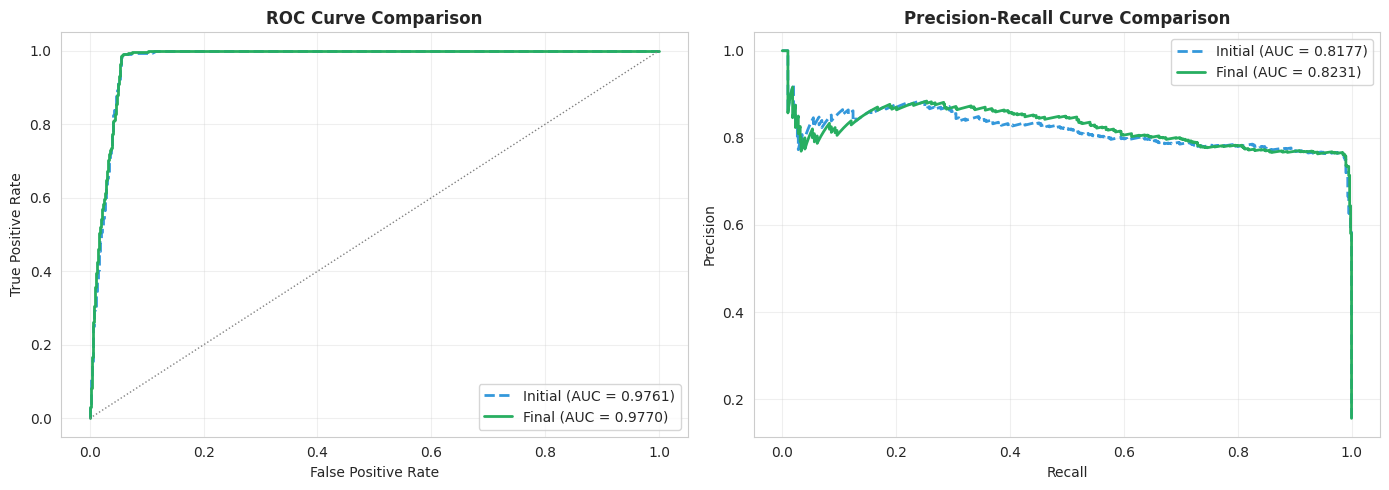

In [32]:
# Final ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve comparison
ax1 = axes[0]
fpr_init, tpr_init, _ = roc_curve(test_labels, test_probs)
fpr_final, tpr_final, _ = roc_curve(test_labels_final, test_probs_final)
ax1.plot(fpr_init, tpr_init, color='#3498db', lw=2, linestyle='--',
         label=f'Initial (AUC = {metrics_initial["auc_roc"]:.4f})')
ax1.plot(fpr_final, tpr_final, color='#27ae60', lw=2,
         label=f'Final (AUC = {metrics_final["auc_roc"]:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# PR Curve comparison
ax2 = axes[1]
prec_init, rec_init, _ = precision_recall_curve(test_labels, test_probs)
prec_final, rec_final, _ = precision_recall_curve(test_labels_final, test_probs_final)
ax2.plot(rec_init, prec_init, color='#3498db', lw=2, linestyle='--',
         label=f'Initial (AUC = {metrics_initial["auc_pr"]:.4f})')
ax2.plot(rec_final, prec_final, color='#27ae60', lw=2,
         label=f'Final (AUC = {metrics_final["auc_pr"]:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve Comparison', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Explainability — Captum (Integrated Gradients)

> *DSO : "Model Interpretability and Explainable AI (XAI)"*

**Captum** est la librairie XAI native PyTorch.  
La méthode **Integrated Gradients** mesure la contribution de chaque feature
à la prédiction en intégrant les gradients depuis une baseline neutre jusqu'à
l'input réel — particulièrement adaptée aux modèles séquentiels comme l'LSTM.

- **Importance globale** → moyenne des attributions sur tout le test set
- **Analyse par timestep** → quelle position dans la séquence a le plus influencé la décision
- **Explication individuelle** → décomposition d'un exemple précis (congestion ou non)

✅ Attributions calculées — shape : torch.Size([200, 30, 7])
   Convergence delta moyen : 0.000561 (< 0.05 = bon)


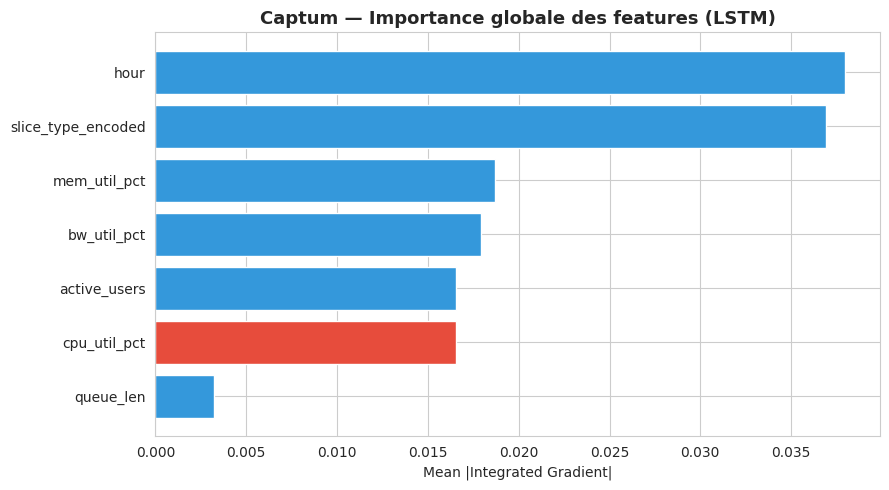

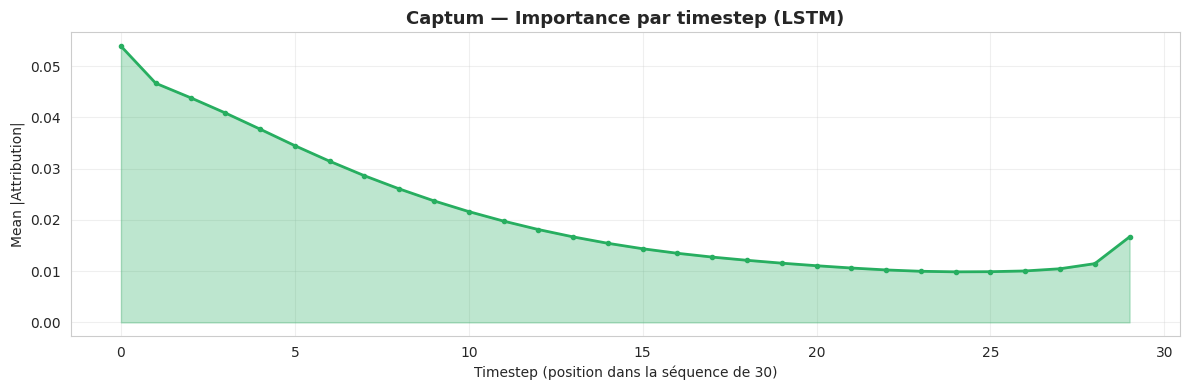

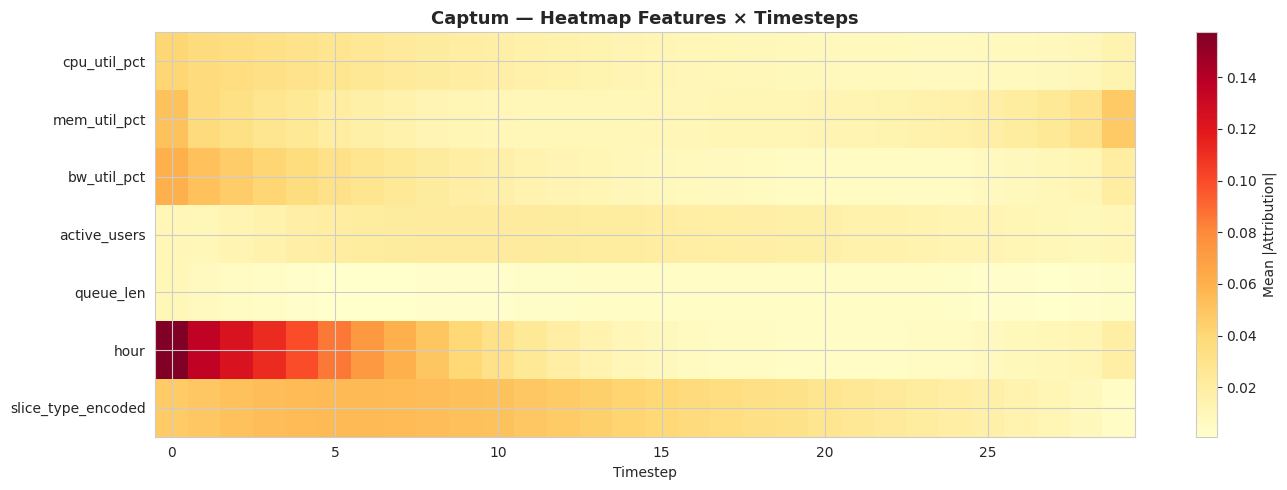

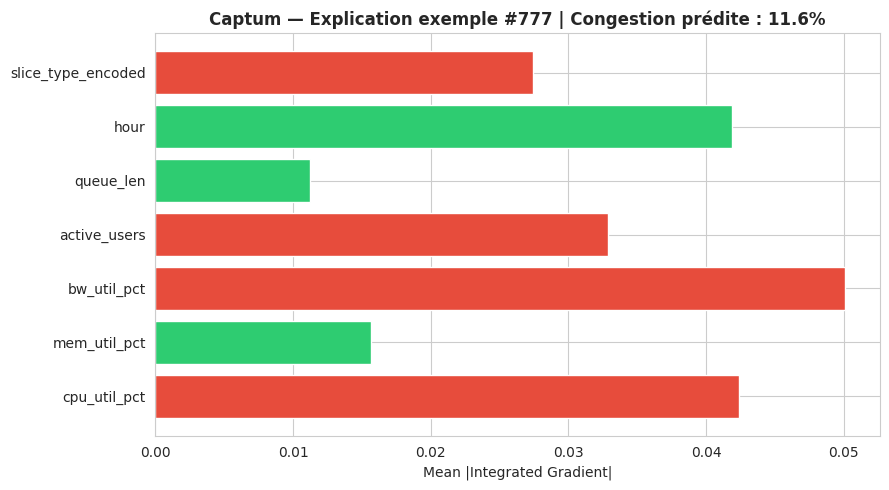


🔍 Exemple #777 — Probabilité de congestion : 11.6%
   Feature la plus influente : bw_util_pct
   Timestep le plus critique : 29


In [37]:
# ============================================================
# EXPLAINABILITY — Captum Integrated Gradients (LSTM PyTorch)
# ============================================================

%pip install captum --quiet

import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

# --- 1. Wrapper du modèle ---
class LSTMWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x).squeeze(-1)

model_wrapped = LSTMWrapper(model_final).to(device)
model_wrapped.eval()

ig = IntegratedGradients(model_wrapped)

# --- 2. Préparer le batch test ---
X_test_tensor = torch.FloatTensor(X_test[:200]).to(device)
baseline      = torch.zeros_like(X_test_tensor)

# --- 3. ✅ FIX — Désactiver cuDNN avant le calcul des gradients ---
torch.backends.cudnn.enabled = False

attributions, delta = ig.attribute(
    X_test_tensor,
    baselines=baseline,
    target=None,
    return_convergence_delta=True
)

# Réactiver cuDNN après
torch.backends.cudnn.enabled = True

print(f"✅ Attributions calculées — shape : {attributions.shape}")
print(f"   Convergence delta moyen : {delta.abs().mean().item():.6f} (< 0.05 = bon)")

feature_names = preprocessor.feature_cols

# --- 4. Importance GLOBALE par feature ---
attr_np    = attributions.cpu().detach().numpy()
global_imp = np.mean(np.abs(attr_np), axis=(0, 1))
sorted_idx = np.argsort(global_imp)[::-1]

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if i == sorted_idx[0] else '#3498db' for i in range(len(feature_names))]
plt.barh(
    [feature_names[i] for i in sorted_idx[::-1]],
    global_imp[sorted_idx[::-1]],
    color=colors[::-1]
)
plt.xlabel("Mean |Integrated Gradient|")
plt.title("Captum — Importance globale des features (LSTM)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 5. Importance par TIMESTEP ---
timestep_imp = np.mean(np.abs(attr_np), axis=(0, 2))

plt.figure(figsize=(12, 4))
plt.plot(timestep_imp, color='#27ae60', linewidth=2, marker='o', markersize=3)
plt.fill_between(range(len(timestep_imp)), timestep_imp, alpha=0.3, color='#27ae60')
plt.xlabel("Timestep (position dans la séquence de 30)")
plt.ylabel("Mean |Attribution|")
plt.title("Captum — Importance par timestep (LSTM)", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 6. Heatmap Features × Timesteps ---
heatmap = np.mean(np.abs(attr_np), axis=0).T

plt.figure(figsize=(14, 5))
plt.imshow(heatmap, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(label='Mean |Attribution|')
plt.yticks(range(len(feature_names)), feature_names)
plt.xlabel("Timestep")
plt.title("Captum — Heatmap Features × Timesteps", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 7. Explication individuelle — exemple congestionné ---
torch.backends.cudnn.enabled = False

y_test_np  = y_test
cong_idx   = np.where(y_test_np == 1)[0]
sample_idx = cong_idx[0]

sample     = torch.FloatTensor(X_test[[sample_idx]]).to(device)
baseline_s = torch.zeros_like(sample)

# ✅ FIX — sans return_convergence_delta sur un sample unique
attr_sample    = ig.attribute(sample, baselines=baseline_s)
attr_sample_np = attr_sample.cpu().detach().numpy()[0]   # (seq_len, n_features)

torch.backends.cudnn.enabled = True

feat_imp_sample = np.mean(np.abs(attr_sample_np), axis=0)
prob = torch.sigmoid(model_wrapped(sample)).item()

plt.figure(figsize=(9, 5))
colors_s = ['#e74c3c' if v > 0 else '#2ecc71'
            for v in np.mean(attr_sample_np, axis=0)]
plt.barh(feature_names, feat_imp_sample, color=colors_s)
plt.xlabel("Mean |Integrated Gradient|")
plt.title(
    f"Captum — Explication exemple #{sample_idx} | Congestion prédite : {prob:.1%}",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\n🔍 Exemple #{sample_idx} — Probabilité de congestion : {prob:.1%}")
print(f"   Feature la plus influente : {feature_names[np.argmax(feat_imp_sample)]}")
print(f"   Timestep le plus critique : {np.argmax(np.mean(np.abs(attr_sample_np), axis=1))}")

In [35]:
# Save final model
torch.save({
    'model_state_dict': model_final.state_dict(),
    'hyperparameters': best_params,
    'preprocessor': preprocessor,
    'threshold': optimal_threshold_final,
    'metrics': metrics_final
}, 'network-slicing-congestion-forecasting.pth')

print("\nFinal model saved")


Final model saved


---
## 10. Summary

In [36]:
print("="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print("\n📊 DATASET:")
print(f"   Total records: {len(df):,}")
print(f"   Features used: {len(preprocessor.feature_cols)}")
print(f"   Sequence length: {preprocessor.seq_length}")
print(f"   Class imbalance: {pos_weight:.2f}:1")

print("\n🎯 FEATURE SELECTION (MI Scores):")
for _, row in mi_df.iterrows():
    print(f"   {row['Feature']}: {row['MI Score']:.4f}")

print("\n🔧 OPTIMAL HYPERPARAMETERS:")
print(f"   Hidden dim: {best_hidden_dim}")
print(f"   Num layers: {best_coarse['num_layers']}")
print(f"   Dropout: {best_dropout:.3f}")
print(f"   Learning rate: {best_lr:.6f}")
print(f"   Bidirectional: {best_coarse['bidirectional']}")

print("\n📈 FINAL MODEL PERFORMANCE:")
for metric, value in metrics_final.items():
    print(f"   {metric}: {value:.4f}")

print("\n✅ ANALYSIS COMPLETE")

ANALYSIS SUMMARY

📊 DATASET:
   Total records: 21,600
   Features used: 7
   Sequence length: 30
   Class imbalance: 2.71:1

🎯 FEATURE SELECTION (MI Scores):
   cpu_util_pct: 0.4797
   bw_util_pct: 0.4641
   queue_len: 0.4469
   slice_type_encoded: 0.3788
   mem_util_pct: 0.3074
   active_users: 0.2982
   hour: 0.0106

🔧 OPTIMAL HYPERPARAMETERS:
   Hidden dim: 124
   Num layers: 2
   Dropout: 0.358
   Learning rate: 0.001168
   Bidirectional: True

📈 FINAL MODEL PERFORMANCE:
   accuracy: 0.9506
   precision: 0.7661
   recall: 0.9834
   f1: 0.8613
   auc_roc: 0.9770
   auc_pr: 0.8231

✅ ANALYSIS COMPLETE
